# Split data into train, val and test 

In [3]:
pip install split-folders

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install numpy pandas matplotlib seaborn termcolor opencv-python tensorflow scikit-learn

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
    --------------------------------------- 0.5/39.5 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.3/39.5 MB 3.2 MB/s eta 0:00:12
   ---- ----------------------------------- 4.2/39.5 MB 7.2 MB/s eta 0:00:05
   ------ --------------------------------- 6.3/39.5 MB 8.0 MB/s eta 0:00:05
   -------- ------------------------------- 8.1/39.5 MB 8.7 MB/s eta 0:00:04
   ---------- ----------------------------- 10.2/39.5 MB 8.6 MB/s eta 0:00:04
   ------------- -------------------------- 12.8/39.5 MB 9.3 MB/s eta 0:00:03
   ---------------- ----------------------- 16.0/39.5 MB 10.0 MB/s eta 0:00:03
   ------------------- -------------------- 19.1/39.5 MB 10.6 MB/s eta 0:00:02
   --------------------------- ------------ 27.0/39.5 MB 13.4 MB/s eta 0:00:01
   ------------------------------------ --- 36.4/39.5 MB 16.4 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 16.8 MB/s eta 0:

import splitfolders

input_folder = "corn_thermo"

splitfolders.ratio(input_folder,output="corn_thermo_split",
                   seed=42,ratio=(0.8,0.2),
                   group_prefix=None)

In [4]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from termcolor import colored
import matplotlib.pyplot as plt
from keras.utils import plot_model
from tensorflow.keras import optimizers
from tensorflow.keras import models, layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam  # Import Adam optimizer
from tensorflow.keras.applications.efficientnet import preprocess_input

# Import images

In [5]:
base_dir = 'corn_thermo_split'

In [6]:
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')

# Count data and classes

In [7]:
def num_of_classes(folder_dir, folder_name) :
    classes = [class_name for class_name in os.listdir(train_dir)]
    print(colored(f'number of classes in {folder_name} folder : {len(classes)}', 'blue', attrs=['bold']))

In [8]:
num_of_classes(train_dir, 'train')
num_of_classes(validation_dir, 'val')

number of classes in train folder : 6
number of classes in val folder : 6


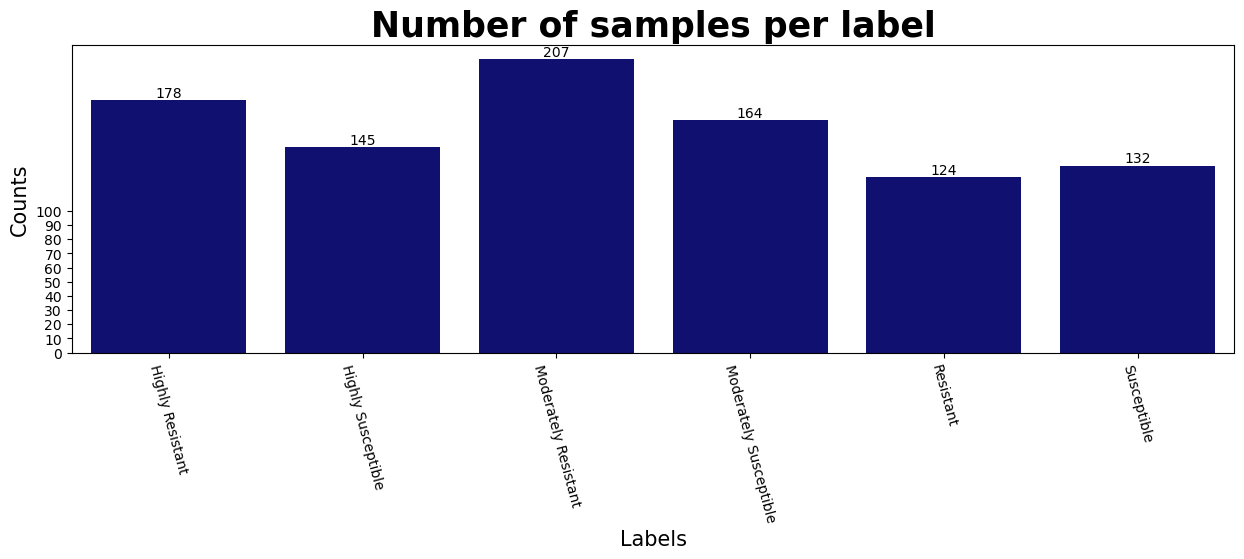

In [9]:
classes = [class_name for class_name in os.listdir(train_dir)]
count = []
for class_name in classes :
    count.append(len(os.listdir(os.path.join(train_dir, class_name))))

plt.figure(figsize=(15, 4))
ax = sns.barplot(x=classes, y=count, color='navy')
plt.xticks(rotation=285)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Number of samples per label', fontsize=25, fontweight='bold')
plt.xlabel('Labels', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.yticks(np.arange(0, 105, 10))
plt.show()

# Convert data to a DataFrame

In [10]:
def create_df(folder_path) :
    all_images = []    
    for class_name in classes :
        class_path = os.path.join(folder_path, class_name)
        all_images.extend([(os.path.join(class_path, file_name), class_name) for file_name in os.listdir(class_path)])
    df = pd.DataFrame(all_images, columns=['file_path', 'label'])
    return df

In [11]:
train_df = create_df(train_dir)
validation_df = create_df(validation_dir)

In [12]:
print(colored(f'Number of samples in train : {len(train_df)}', 'blue', attrs=['bold']))
print(colored(f'Number of samples in validation : {len(validation_df)}', 'blue', attrs=['bold']))

Number of samples in train : 950
Number of samples in validation : 242


# Show an image per each class(label)

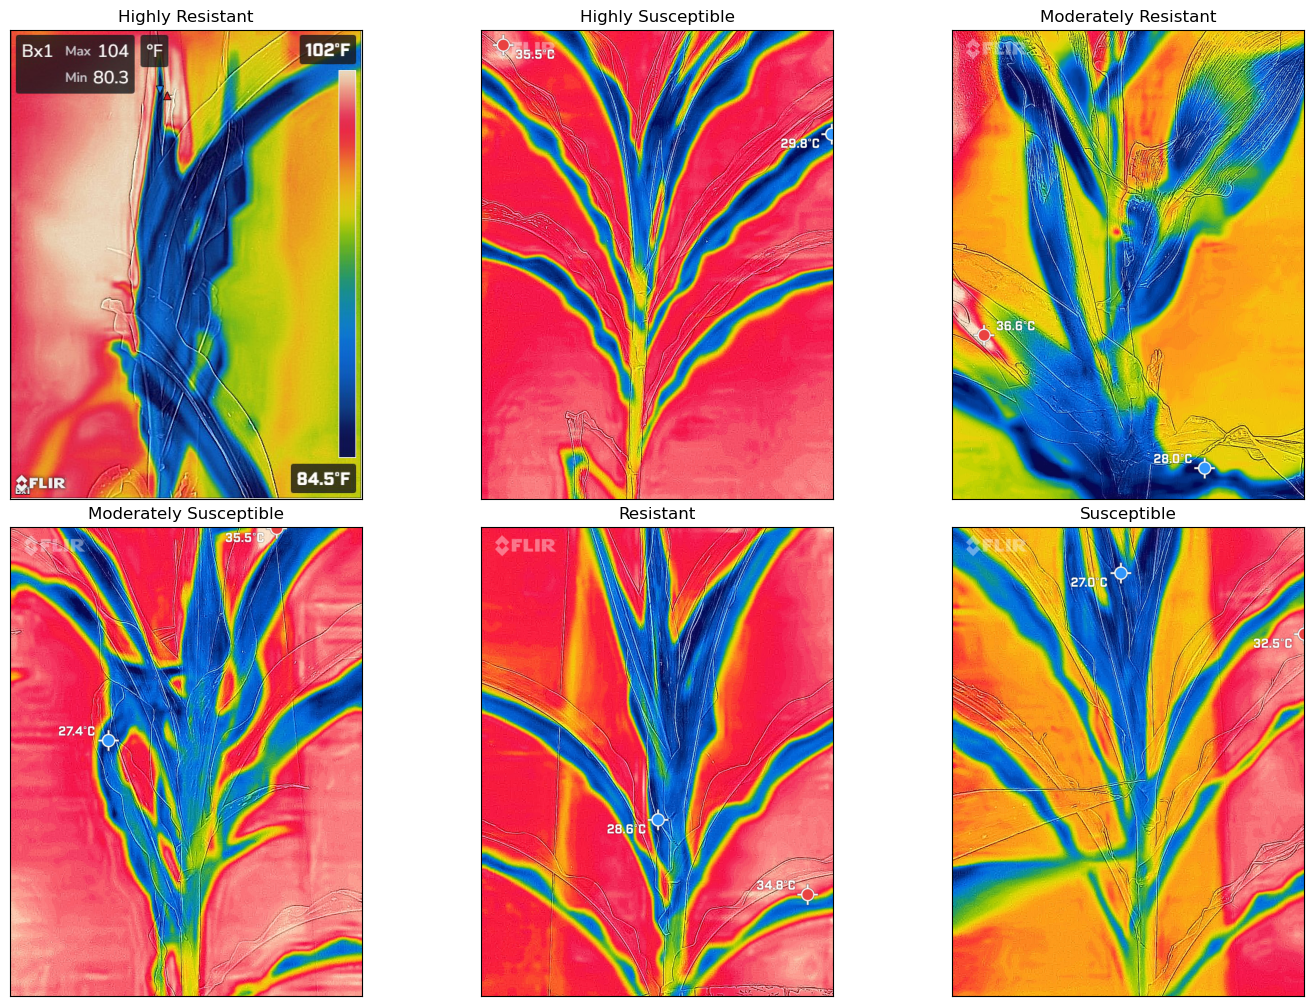

In [13]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.file_path[i]))
    ax.set_title(df_unique.label[i], fontsize = 12)
plt.tight_layout(pad=0.5)
plt.show()

# Data generators

In [14]:
# Define the training data generator with EfficientNet preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Apply EfficientNet preprocessing
    shear_range=0.1,                         # Shear images by 10% of their size
    rotation_range=10,  # Increased from 25
    width_shift_range=0.3,  # More translation
    height_shift_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='constant'
)

# Create the training data generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,                      # Target data
    x_col='file_path',                       # X column (file paths)
    y_col='label',                           # y column (labels)
    target_size=(300, 300),                  # Resize images to 300x300
    color_mode='rgb',                        # Color mode (RGB)
    class_mode='categorical',                # Type of model (categorical for multi-class classification)
    batch_size=32,                           # Batch size
    shuffle=True,                            # Shuffle the data
    seed=42                                  # Random seed for reproducibility
)

Found 950 validated image filenames belonging to 6 classes.


In [15]:
# Define the validation data generator with EfficientNet preprocessing
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # Apply EfficientNet preprocessing
)

# Create the validation data generator
validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,                 # Target data
    x_col='file_path',                       # X column (file paths)
    y_col='label',                           # y column (labels)
    target_size=(300, 300),                  # Resize images to 300x300
    color_mode='rgb',                        # Color mode (RGB)
    class_mode='categorical',                # Type of model (categorical for multi-class classification)
    batch_size=32,                           # Batch size
    shuffle=False                            # Do not shuffle validation data
)

Found 242 validated image filenames belonging to 6 classes.


In [16]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),  # Classes in the training data
    y=train_generator.classes                   # Labels in the training data
)
class_weights = dict(enumerate(class_weights))  # Convert to a dictionary

# Print class weights
print("Class Weights:", class_weights)

Class Weights: {0: 0.8895131086142322, 1: 1.0919540229885059, 2: 0.7648953301127214, 3: 0.9654471544715447, 4: 1.2768817204301075, 5: 1.1994949494949494}


# Add EfficientNetb3 model

In [17]:
pre_trained_model = EfficientNetB3(
    input_shape=(300, 300, 3),  # Input image size
    include_top=False,          # Exclude the classification head
    weights='imagenet',         # Use pre-trained weights
    pooling='avg'               # Use global average pooling
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [18]:
from tensorflow.keras import layers, models

# Ensure the pre-trained model is frozen
pre_trained_model.trainable = False

# Define the input
inputs = layers.Input(shape=(300, 300, 3))

# Use the pre-trained model as a feature extractor
x = pre_trained_model(inputs, training=False)

# Add a fully connected layer
x = layers.Dense(256, activation='relu')(x)

# Add the output layer for 6 classes
outputs = layers.Dense(6, activation='softmax')(x)

# Create the final model
model = models.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',  # Use 'sparse_categorical_crossentropy' for integer labels
    metrics=['accuracy']
)

# Print the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,549 (42.64 MB)

 Trainable params: 395,014 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [19]:
# Unfreeze the top layers of the pre-trained model
# Example: Unfreeze the last 10 layers
for layer in pre_trained_model.layers[-10:]:
    layer.trainable = True

# Recompile the model to apply the changes
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Use a lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print the updated model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,549 (42.64 MB)

 Trainable params: 2,096,902 (8.00 MB)

 Non-trainable params: 9,081,647 (34.64 MB)

# Callbacks

In [20]:
checkpoint_cb = ModelCheckpoint('corn_thermo.keras', save_best_only=True) 

# Early Stoping
earlystop_cb = EarlyStopping(patience=5, restore_best_weights=True)

# ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train Model

In [21]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,  # Fine-tune for a few epochs
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr],
    class_weight=class_weights  # Use class weights during fine-tuning
)

C:\Users\shuns\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 170s 5s/step - accuracy: 0.3478 - loss: 1.6430 - val_accuracy: 0.7562 - val_loss: 1.0411 - learning_rate: 1.0000e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.7423 - loss: 0.9846 - val_accuracy: 0.8264 - val_loss: 0.6918 - learning_rate: 1.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - accuracy: 0.8528 - loss: 0.6864 - val_accuracy: 0.8760 - val_loss: 0.4885 - learning_rate: 1.0000e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.8808 - loss: 0.4931 - val_accuracy: 0.9174 - val_loss: 0.3700 - learning_rate: 1.0000e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 134s 4s/step - accuracy: 0.8820 - loss: 0.4342 - val_accuracy: 0.9339 - val_loss: 0.3043 - learning_rate: 1.0000e-04
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 128s 4s/step - accuracy: 0.9487 - loss: 0.2840 - val_accuracy: 0.9545 - val_loss: 0.2437 - learning_rate: 1.0000e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 120s 4s/step - accuracy: 0.9384 

# Plot the result of training

In [22]:
# Convert resutl of training to a DataFrame
result_df = pd.DataFrame(history.history)
result_df.tail()

,accuracy,loss,val_accuracy,val_loss,learning_rate
25,0.977895,0.072962,0.991736,0.036369,0.00010
26,0.983158,0.061225,0.991736,0.041292,0.00010
27,0.969474,0.076641,0.966942,0.067422,0.00010
28,0.986316,0.060000,0.983471,0.050334,0.00005
29,0.985263,0.058611,0.991736,0.034599,0.00005


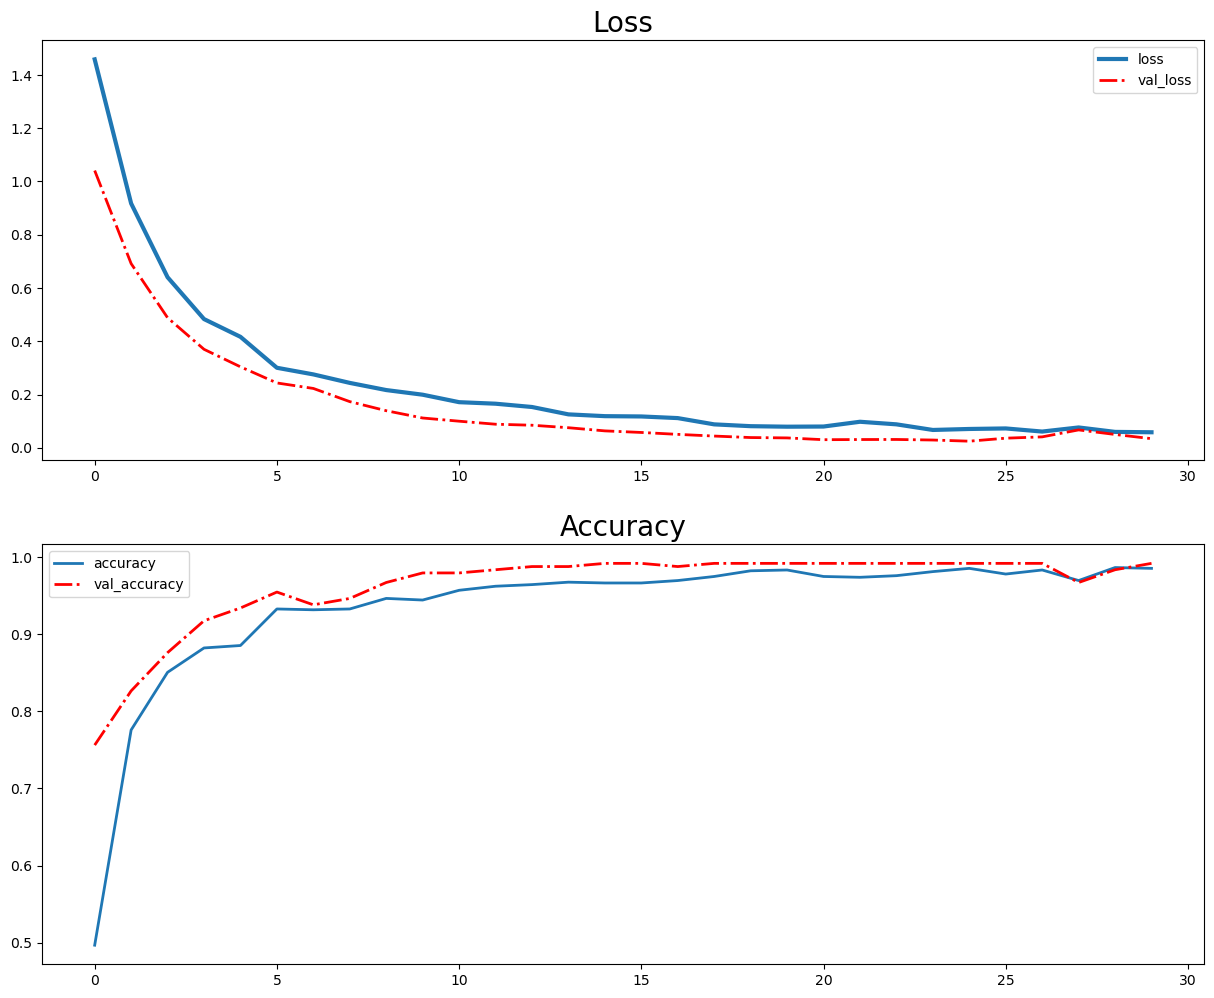

In [23]:
x = np.arange(len(result_df))
fig, ax = plt.subplots(2, 1, figsize=(15, 12))
#  AX0 : Loss
ax[0].plot(x, result_df.loss, label='loss', linewidth=3)
ax[0].plot(x, result_df.val_loss, label='val_loss', linewidth=2, ls='-.', c='r')
ax[0].set_title('Loss', fontsize=20)
ax[0].legend()

#  AX1 : Loss
ax[1].plot(x, result_df.accuracy, label='accuracy', linewidth=2)
ax[1].plot(x, result_df.val_accuracy, label='val_accuracy', linewidth=2, ls='-.', c='r')
ax[1].set_title('Accuracy', fontsize=20)
ax[1].legend()

plt.sharex=True


plt.show()

# Evaluate the Model

In [25]:
best_model = models.load_model('corn_thermo.keras')

In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model_performance(model, val_generator, custom_order):
    """
    Evaluate the model's performance on the validation set and print the classification report.

    Parameters:
    - model: The trained model.
    - val_generator: Validation data generator.
    - custom_order: List defining the desired class order.

    Returns:
    - report: Classification report as a string.
    """

    # True labels from validation generator
    true_labels = val_generator.classes

    # Get the class labels from the generator
    original_class_labels = list(val_generator.class_indices.keys())

    # Get predictions from the model
    predictions = model.predict(val_generator, steps=len(val_generator))
    
    # Convert to predicted class indices
    predicted_labels = np.argmax(predictions, axis=1)

    # Rearrange class labels based on custom order
    class_order = [original_class_labels.index(cls) for cls in custom_order]

    # Rearrange confusion matrix accordingly
    cm = confusion_matrix(true_labels, predicted_labels)
    cm = cm[np.ix_(class_order, class_order)]  # Reorder rows & columns

    # Print classification report with reordered labels
    report = classification_report(true_labels, predicted_labels, target_names=original_class_labels)
    print(report, '\n')

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=custom_order, yticklabels=custom_order, cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix (Reordered)')
    plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
                        precision    recall  f1-score   support

      Highly Resistant       1.00      1.00      1.00        45
    Highly Susceptible       1.00      0.97      0.99        37
  Moderately Resistant       1.00      1.00      1.00        52
Moderately Susceptible       1.00      0.98      0.99        42
             Resistant       1.00      1.00      1.00        32
           Susceptible       0.94      1.00      0.97        34

              accuracy                           0.99       242
             macro avg       0.99      0.99      0.99       242
          weighted avg       0.99      0.99      0.99       242
 



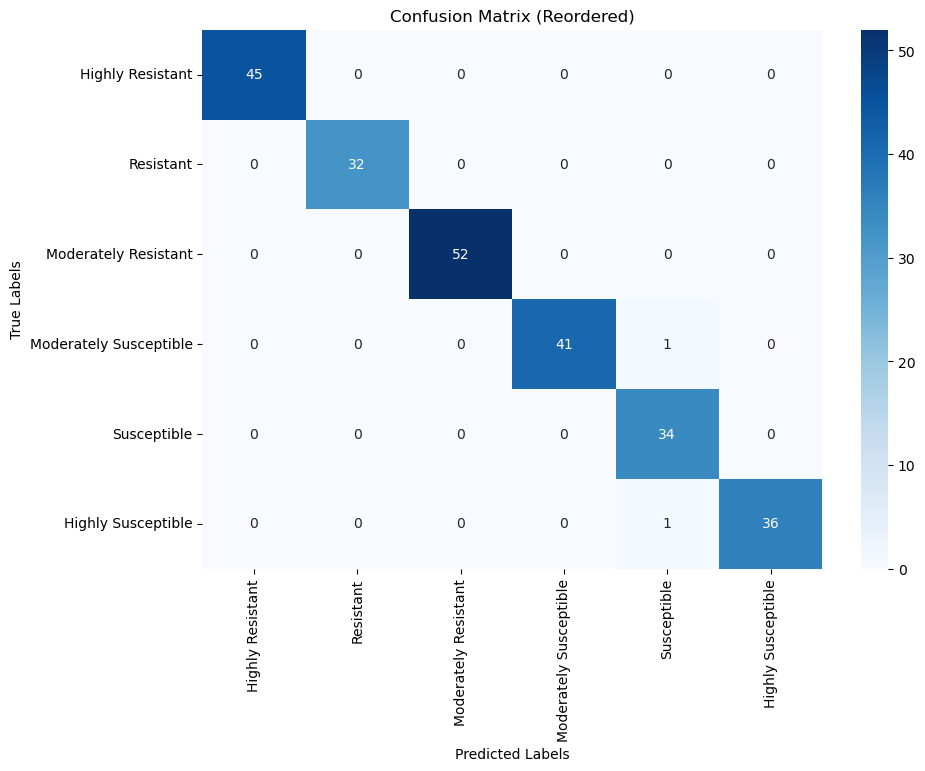

In [28]:
custom_class_order = ['Highly Resistant', 'Resistant', 'Moderately Resistant', 'Moderately Susceptible', 'Susceptible', 'Highly Susceptible']

evaluate_model_performance(best_model, validation_generator, custom_class_order)